# **MÓDULO 20 - Projeto de Credit Score - Naive Bayes**


No módulo 17 vocês realizaram a primeira etapa do projeto de crédito de vocês.
Então fizeram o tratamendo dos dados, balancearam as classes, transformaram as variáveis categóricas e separam base de treino e teste.
Nessa aula aplicaremos o algoritmo de naive bayes a base de vocês afim de tentarmos trazer previsões do score de crédito.

**IMPORTANTE:** Não se esqueçam de ao enviar o código de vocês para os tutores, enviarem as bases, pois como cada um de vocês realizou as alterações de tratamento indidualmente o tutor precisa ter acesso aos seus dados individuais.

In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import recall_score
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv('dados_processados_M20.csv')

Durante a aula nossa variável a ser prevista (churn) continha apenas 2 categorias, a base de vocês contém mais. O Naive Bayes pode ser aplicado para problemas de classificação com múltiplas classes da mesma forma que para problemas de classificação binária. O Naive Bayes é um algoritmo de classificação probabilístico que calcula a probabilidade de uma amostra pertencer a cada classe e seleciona a classe com a maior probabilidade como a previsão final.
Em resumo, o Naive Bayes pode ser aplicado da mesma maneira para problemas de classificação com múltiplas classes, e os mesmos princípios se aplicam em termos de treinamento, avaliação e aplicação do modelo.

# 1) Comece carregando as bases de treino (X e y) e teste (X e y).
Verifique se o número de linhas condiz, se as variáveis estão corretas sendo apenas a de score para y e as demais nas bases de X e por último, se Y está balanceada no teste.

In [8]:
print(df.columns.tolist())

['Age', 'Income', 'Number of Children', 'Credit Score', 'Gender_Female', 'Gender_Male', "Education_Associate's Degree", "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Married', 'Marital Status_Single', 'Home Ownership_Owned', 'Home Ownership_Rented']


In [10]:
coluna_target = 'Credit Score'

X = df.drop(columns=[coluna_target])
y = df[coluna_target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [12]:
print("--- Dimensões das bases ---")
print(f"Treino -> X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Teste  -> X_test:  {X_test.shape}, y_test:  {y_test.shape}")

--- Dimensões das bases ---
Treino -> X_train: (114, 14), y_train: (114,)
Teste  -> X_test:  (50, 14), y_test:  (50,)


In [16]:
print("\n Coluna de y")
print(y.name)

print("\n Variáveis em X")
print(X.columns.tolist())


 Coluna de y
Credit Score

 Variáveis em X
['Age', 'Income', 'Number of Children', 'Gender_Female', 'Gender_Male', "Education_Associate's Degree", "Education_Bachelor's Degree", 'Education_Doctorate', 'Education_High School Diploma', "Education_Master's Degree", 'Marital Status_Married', 'Marital Status_Single', 'Home Ownership_Owned', 'Home Ownership_Rented']


In [19]:
print(y_test.value_counts(normalize=True))

Credit Score
3.0    0.68
2.0    0.22
1.0    0.10
Name: proportion, dtype: float64


# 2) Aplique o algoritmo de Naive Bayes aos dados de treinamento.

In [20]:
modelo_NB = GaussianNB()

modelo_NB.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


# 3) Faça a avaliação do modelo com os dados de treinamento.
Traga a acurácia, recall e plote a matriz de confusão. Não se esqueça de avaliar com suas palavras o desempenho do modelo, interpretando as métricas.

Dica: Para calcularmos o recall em classificação multi classe precisamos usar o atributo macro:
recall = recall_score(y_train, y_pred_train, average='macro')

In [22]:
y_pred_train = modelo_NB.predict(X_train)

In [23]:
acc_train = accuracy_score(y_train, y_pred_train)
rec_train = recall_score(y_train, y_pred_train, average='macro')

print(f"Acurácia (Treino): {acc_train:.4f}")
print(f"Recall (Treino):   {rec_train:.4f}")

Acurácia (Treino): 0.9912
Recall (Treino):   0.9958


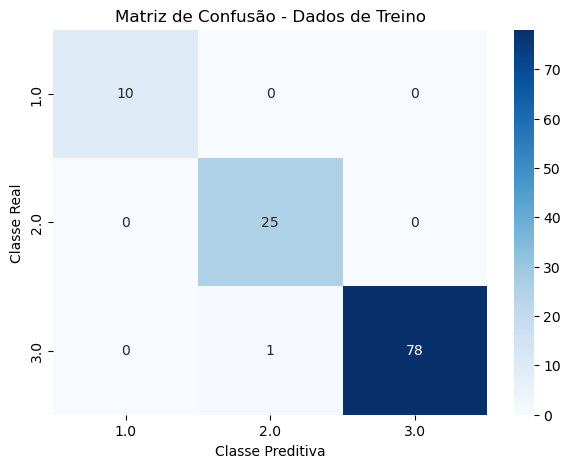

In [24]:
cm_train = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_train), 
            yticklabels=np.unique(y_train))
plt.title('Matriz de Confusão - Dados de Treino')
plt.xlabel('Classe Preditiva')
plt.ylabel('Classe Real')
plt.show()

In [ ]:
# O algoritmo Naive Bayes apresentou um desempenho quase perfeito nos dados de treinamento,
# com acurácia de 99,12% e recall macro de 99,58%. Esse resultado mostra que o modelo aprendeu muito bem
# os padrões da base de treino

# 4) Aplique o modelo aos dados de teste e realize a avaliação dos resultados, da mesma forma que fez acima. Não se esqueça de avaliar com as suas palavras e comparar o desempenho da base treino com a teste.

In [25]:
y_pred_test = modelo_NB.predict(X_test)

In [26]:
acc_test = accuracy_score(y_test, y_pred_test)
rec_test = recall_score(y_test, y_pred_test, average='macro')

print(f"Acurácia (Teste): {acc_test:.4f}")
print(f"Recall (Teste):   {rec_test:.4f}")

Acurácia (Teste): 0.9800
Recall (Teste):   0.9697


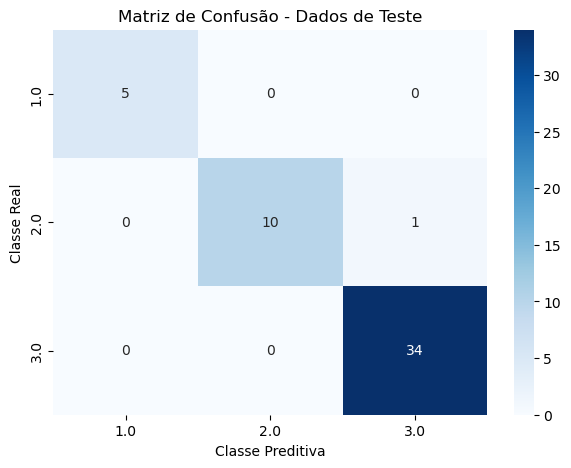

In [27]:
cm_test = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))
plt.title('Matriz de Confusão - Dados de Teste')
plt.xlabel('Classe Preditiva')
plt.ylabel('Classe Real')
plt.show()

In [ ]:
# O modelo Naive Bayes apresentou uma capacidade de generalização excelente.
# A matriz de confusão do teste revela apenas 1 erro em 50 observações, 
# enquanto as classes 1.0 e 3.0 obtiveram 100% de acerto.
# A variação mínima nas métricas entre treino e teste confirma que o algoritmo
# conseguiu aprender os padrões fundamentais dos dados.

# 5) Descreva com suas palavras o projeto desenvolvido nessa atividade e qual o nosso objetivo principal ao aplicarmos o algoritmo de naive bayes a base de crédito.
Utilize pelo menos 4 linhas.

Dica: Caso você ainda esteja tendo dificuldade em visualizar a aplicação dos projetos e objetivo, consulte seus tutores!

In [ ]:
# O objetivo principal de aplicar o Naive Bayes nesse contexto é aproveitar a sua abordagem probabilística
# para calcular a probabilidade de um cliente pertencer a determinada classe de score com base em suas
# características socioeconômicas (como idade, renda e escolaridade). Por ser um algoritmo rápido, eficiente e com boa
# performance em variáveis contínuas e categóricas, ele permite automatizar a análise de crédito de forma preditiva,
# reduzindo a inadimplência e agilizando a tomada de decisão no momento da concessão de crédito.